# Импорты

In [2]:
import os
import numpy as np

from utils.load_graph import load_graph_from_file, get_edges_from_adj

from dijkstra import dijkstra_classic_heap, dijkstra_quantum
from bellman_ford import bellman_ford_classic, bellman_ford_quantum
from floyd_warshall import (
    adj_to_matrix, floyd_warshall_classic, floyd_warshall_quantum,
)

from utils.measurement import (
    list_dataset_files, measure_algorithm,
    dijkstra_input, bellman_ford_input, floyd_warshall_input,
)
from utils.plotting import plot_comparison

BASE_DIR = ".dataset"

In [3]:
def assert_algo_on_dataset(classic_func, quantum_func, prepare_input,
                            algo_name, base_dir=BASE_DIR, max_n=None):
    files_by_type = list_dataset_files(base_dir)
    failed = 0
    total = 0

    for g_type, files in files_by_type.items():
        for n, filepath in files:
            if max_n is not None and n > max_n:
                continue
            adj, n_ver, m_edg = load_graph_from_file(filepath)
            edges = get_edges_from_adj(adj)
            args = prepare_input(adj, n_ver, edges)
            total += 1

            random_seed = hash(filepath) & 0xFFFF
            np.random.seed(random_seed)
            import random
            random.seed(random_seed)

            d_q, _ = quantum_func(*args)
            d_c, _ = classic_func(*args)

            fname = os.path.basename(filepath)
            try:
                assert d_q == d_c, f"{fname}: quantum != classic"
            except AssertionError as e:
                failed += 1
                print(f"  FAIL: {e}")

    print(f"[{algo_name}] {total - failed}/{total} пройдено")
    assert failed == 0, f"{algo_name}: {failed} тест(ов) провалено"
    return total


In [4]:
assert_algo_on_dataset(
    dijkstra_classic_heap, dijkstra_quantum, dijkstra_input, "Dijkstra",
)

[Dijkstra] 21/21 пройдено


21

In [5]:
assert_algo_on_dataset(
    bellman_ford_classic, bellman_ford_quantum, bellman_ford_input, "Bellman-Ford"
)

[Bellman-Ford] 21/21 пройдено


21

In [7]:
assert_algo_on_dataset(
    floyd_warshall_classic, floyd_warshall_quantum, floyd_warshall_input, "Floyd-Warshall", max_n=200
)

[Floyd-Warshall] 6/6 пройдено


6

# Сравнение classic vs quantum: время и число операций

## Dijkstra

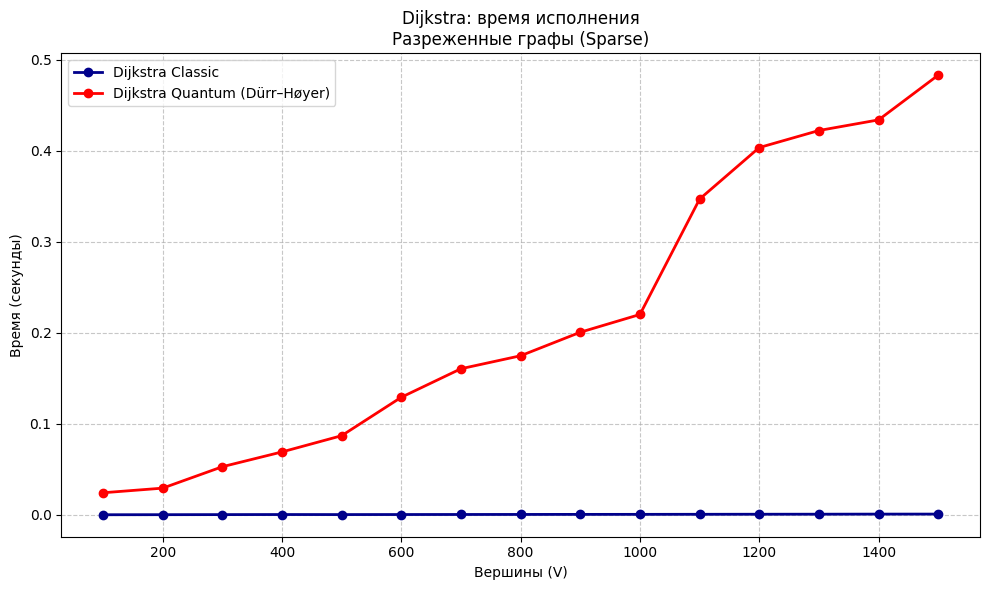

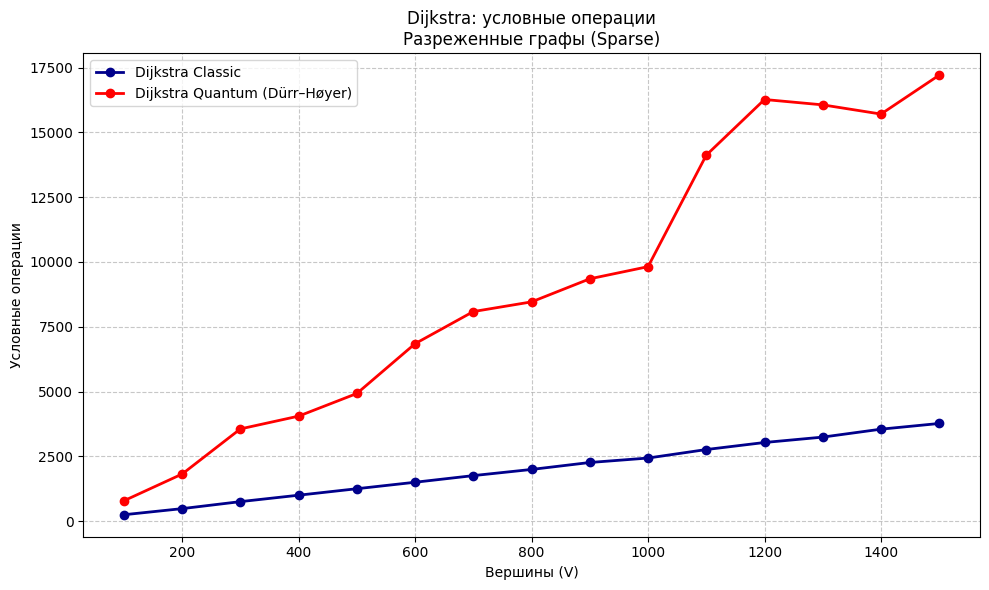

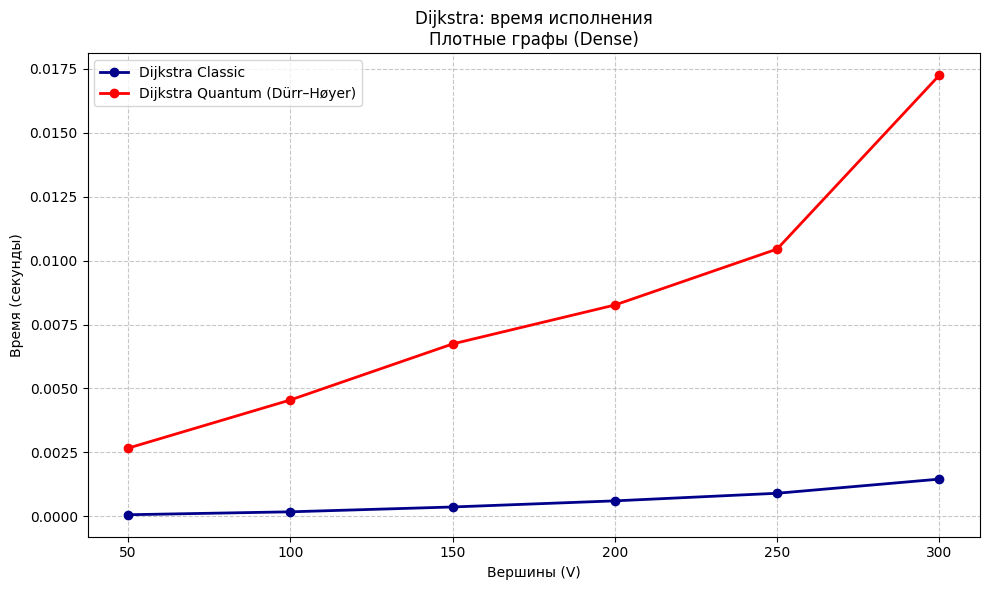

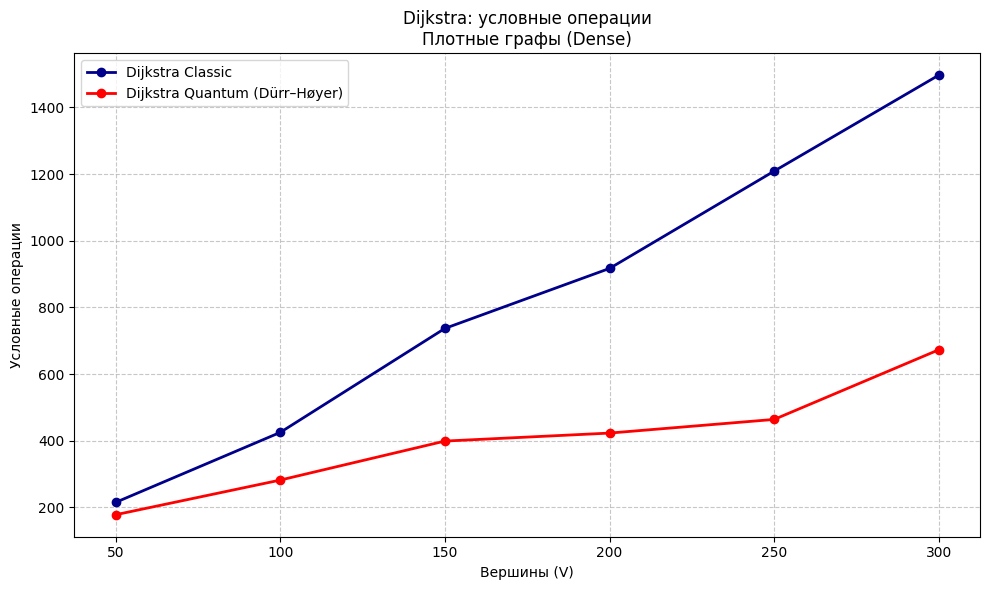

In [8]:
files_by_type = list_dataset_files(BASE_DIR)

dijkstra_classic_res = measure_algorithm(dijkstra_classic_heap, files_by_type, dijkstra_input)
dijkstra_quantum_res = measure_algorithm(dijkstra_quantum, files_by_type, dijkstra_input)

plot_comparison(dijkstra_classic_res, dijkstra_quantum_res, "Dijkstra")

## Bellman-Ford

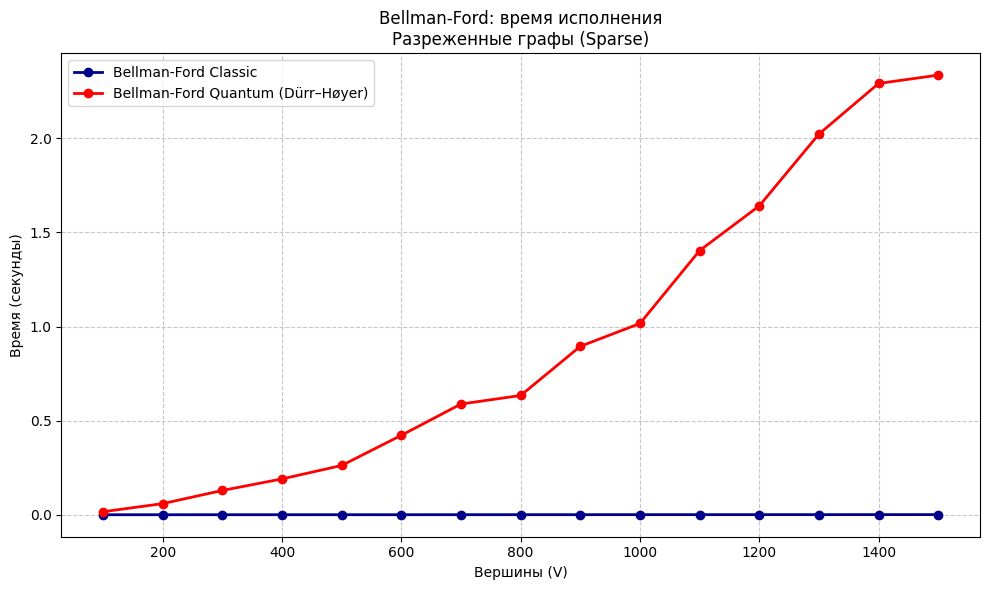

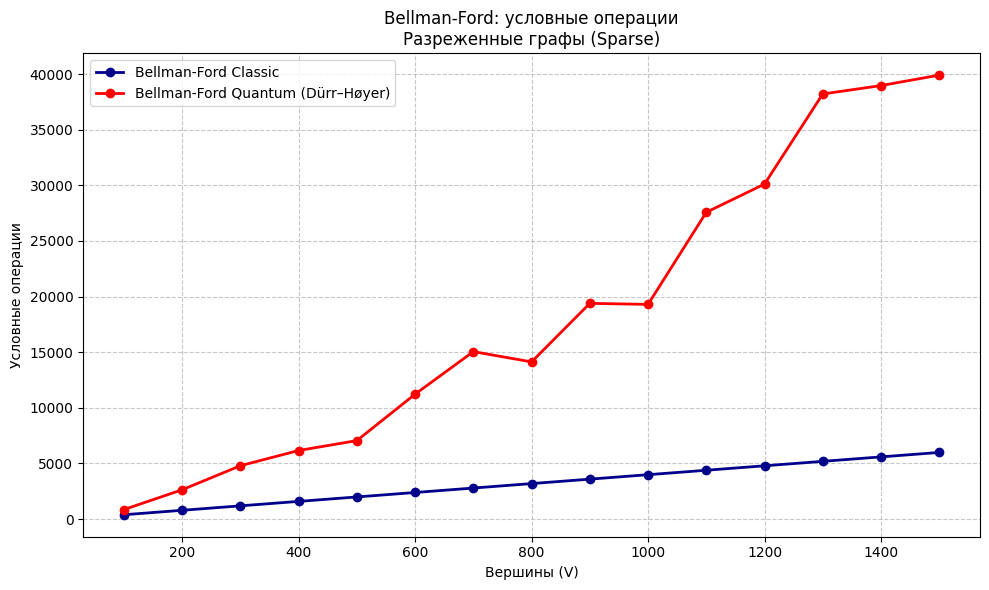

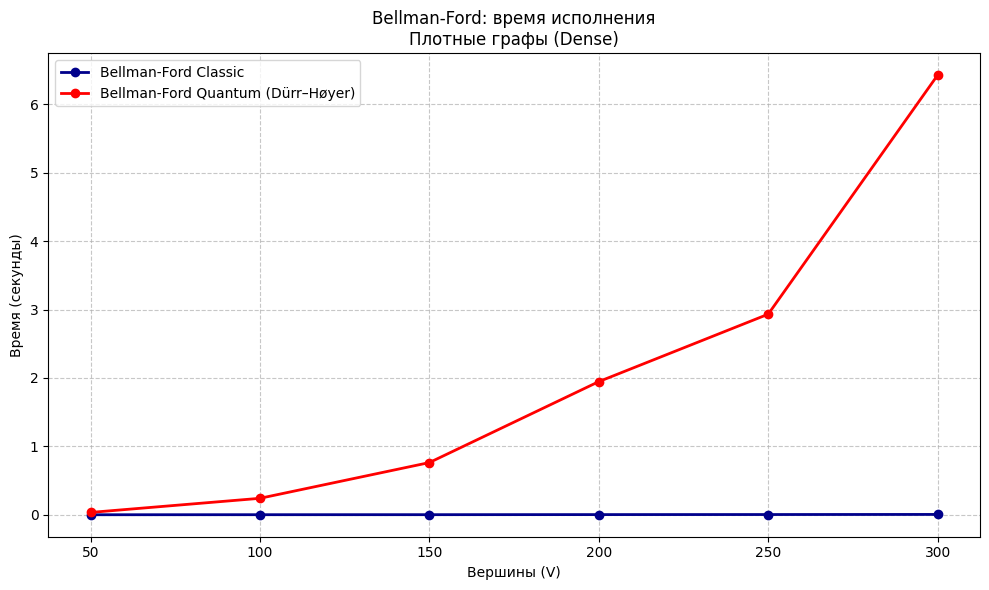

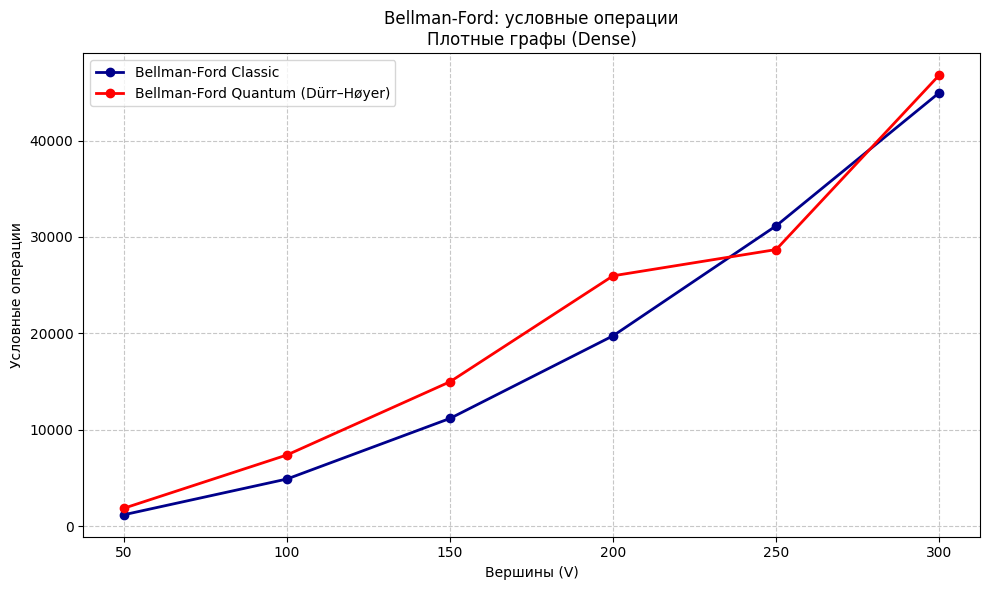

In [9]:
bf_classic_res = measure_algorithm(bellman_ford_classic, files_by_type, bellman_ford_input)
bf_quantum_res = measure_algorithm(bellman_ford_quantum, files_by_type, bellman_ford_input)

plot_comparison(bf_classic_res, bf_quantum_res, "Bellman-Ford")

## Floyd-Warshall

In [10]:
fw_classic_res = measure_algorithm(floyd_warshall_classic, files_by_type, floyd_warshall_input)
fw_quantum_res = measure_algorithm(floyd_warshall_quantum, files_by_type, floyd_warshall_input)

plot_comparison(fw_classic_res, fw_quantum_res, "Floyd-Warshall")

KeyboardInterrupt: 